# Protein Thermostability - EDA

## Background

Thermophilic proteins come from organisms that live in extreme heat (hot springs, deep sea vents). They're more stable at high temps. Can we predict this from the amino acid sequence?

## Data

UniProt SwissProt - 8,250 thermophilic + 8,250 mesophilic = 16,500 total proteins. Sequences filtered by length and standard amino acids.

## Load and explore

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set a consistent visual style for all plots
sns.set_theme(style='whitegrid', palette='muted')

# Load the feature matrix computed from protein sequences
# Path('../data/features.csv') navigates one level up from notebooks/
df = pd.read_csv(Path('../data/features.csv'))

# Basic inspection
print(f"Dataset shape: {df.shape}")
print(f"Proteins: {df.shape[0]}, Features: {df.shape[1]-1}")
df.head()

Dataset shape: (16500, 430)
Proteins: 16500, Features: 429


,AA_A,AA_C,AA_D,AA_E,AA_F,AA_G,AA_H,AA_I,AA_K,AA_L,...,DP_YN,DP_YP,DP_YQ,DP_YR,DP_YS,DP_YT,DP_YV,DP_YW,DP_YY,label
0,0.058366,0.000000,0.058366,0.089494,0.015564,0.070039,0.007782,0.089494,0.085603,0.116732,...,0.00000,0.000000,0.0,0.000000,0.003906,0.000000,0.00000,0.0,0.003906,1
1,0.109910,0.005405,0.072072,0.063063,0.030631,0.097297,0.023423,0.088288,0.084685,0.090090,...,0.00000,0.001805,0.0,0.000000,0.003610,0.001805,0.00000,0.0,0.001805,1
2,0.067416,0.000000,0.033708,0.089888,0.044944,0.022472,0.011236,0.056180,0.078652,0.146067,...,0.00000,0.000000,0.0,0.022727,0.000000,0.000000,0.00000,0.0,0.000000,0
3,0.049439,0.007136,0.039755,0.048930,0.015291,0.100917,0.015291,0.027523,0.049949,0.057594,...,0.00153,0.001020,0.0,0.000000,0.001530,0.001020,0.00051,0.0,0.000000,0
4,0.146006,0.013774,0.049587,0.090909,0.019284,0.063361,0.033058,0.011019,0.005510,0.107438,...,0.00000,0.002762,0.0,0.002762,0.002762,0.000000,0.00000,0.0,0.000000,0


## Check for missing values

In [3]:
# Check missing values - isnull() returns True/False for each cell,
# .sum() counts the Trues per column
missing = df.isnull().sum()
print("Missing values per feature:")
print(missing[missing > 0] if missing.sum() > 0
      else "No missing values found.")

# Remove duplicates
before = len(df)
df = df.drop_duplicates()   # remove identical rows
df = df.dropna()            # remove rows with any NaN
print(f"Removed {before - len(df)} duplicate/NaN rows.")
print(f"Clean dataset shape: {df.shape}")

Missing values per feature:
No missing values found.
Removed 0 duplicate/NaN rows.
Clean dataset shape: (16500, 430)
Removed 0 duplicate/NaN rows.
Clean dataset shape: (16500, 430)


## Class balance

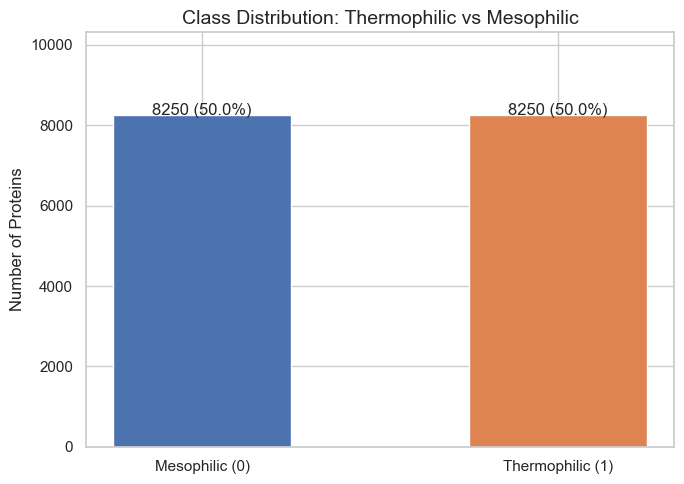

In [4]:
# Count proteins per class
counts = df['label'].value_counts().sort_index()
names = ['Mesophilic (0)', 'Thermophilic (1)']

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(names, counts.values,
              color=['#4C72B0', '#DD8452'], width=0.5)

# Add count labels on top of each bar
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 3,
            f'{count} ({count/len(df)*100:.1f}%)',
            ha='center', fontsize=12)

ax.set_title('Class Distribution: Thermophilic vs Mesophilic',
             fontsize=14)
ax.set_ylabel('Number of Proteins', fontsize=12)
ax.set_ylim(0, max(counts.values) * 1.25)
plt.tight_layout()
plt.savefig('../data/class_distribution.png', dpi=150)
plt.show()

## Feature stats

In [5]:
# Separate features from label
X = df.drop('label', axis=1)   # all columns except 'label'
y = df['label']                 # just the label column

# .describe() returns count, mean, std, min, quartiles, max
# .T transposes the table so features are rows (easier to read)
# .round(3) limits decimal places for readability
stats = X.describe().T.round(3)
print("Feature statistics:")
stats

Feature statistics:


,count,mean,std,min,25%,50%,75%,max
AA_A,16500.0,0.075,0.030,0.0,0.054,0.071,0.092,0.354
AA_C,16500.0,0.014,0.017,0.0,0.003,0.010,0.019,0.390
AA_D,16500.0,0.049,0.018,0.0,0.038,0.049,0.060,0.197
AA_E,16500.0,0.078,0.032,0.0,0.058,0.076,0.096,0.280
AA_F,16500.0,0.038,0.018,0.0,0.027,0.037,0.048,0.194
...,...,...,...,...,...,...,...,...
DP_YS,16500.0,0.002,0.003,0.0,0.000,0.000,0.003,0.053
DP_YT,16500.0,0.002,0.003,0.0,0.000,0.000,0.003,0.032
DP_YV,16500.0,0.002,0.003,0.0,0.000,0.000,0.004,0.038
DP_YW,16500.0,0.000,0.001,0.0,0.000,0.000,0.000,0.020


## Feature distributions by class

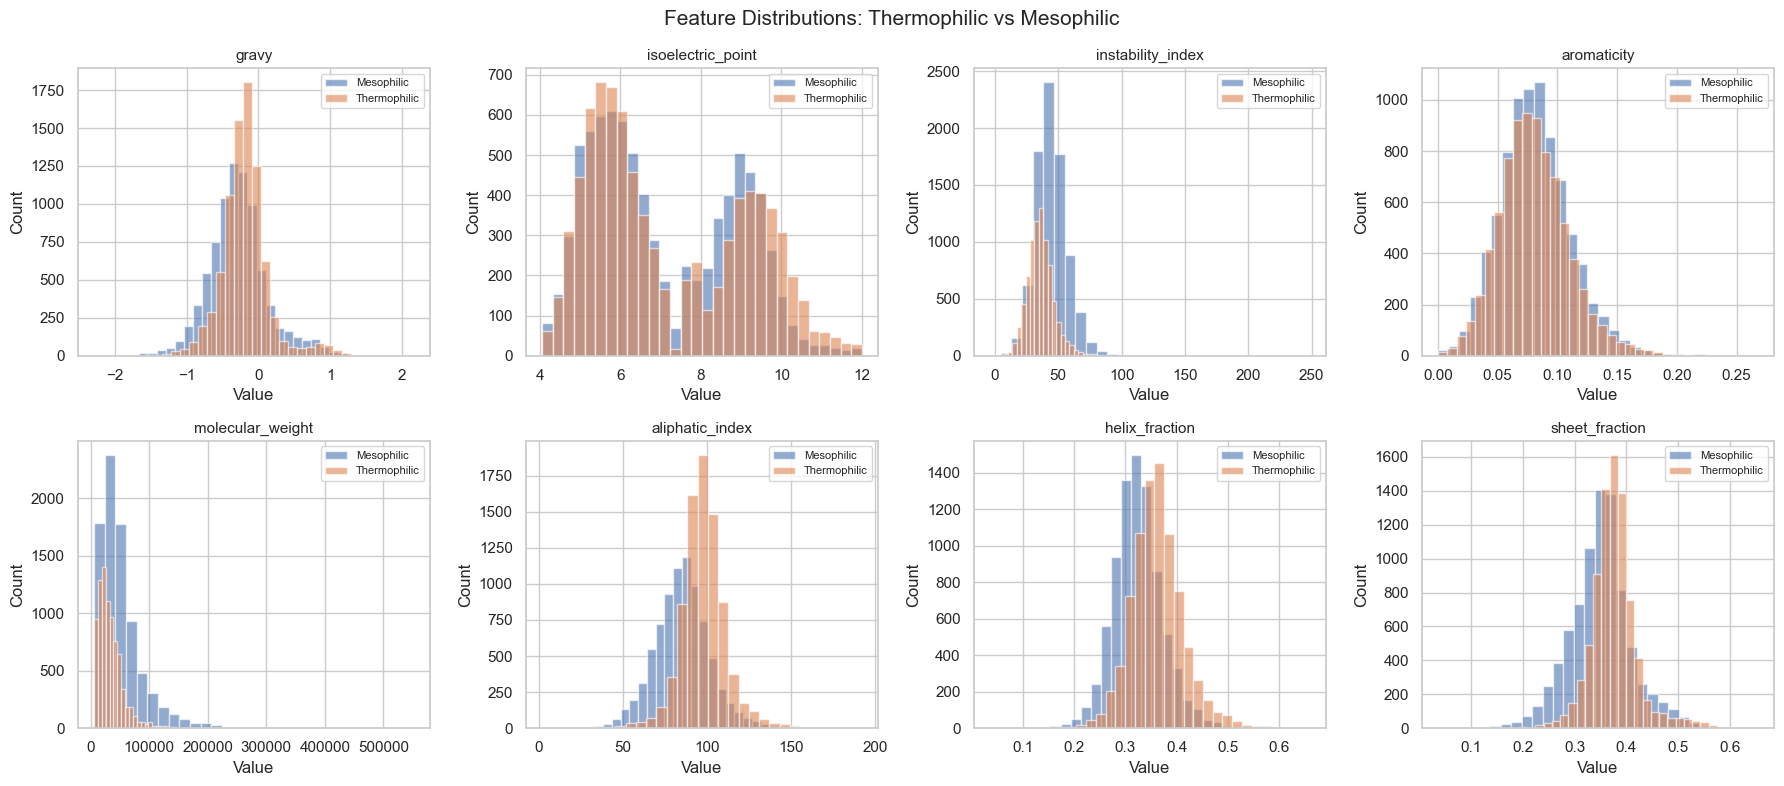

In [6]:
# The 8 most biologically interpretable physicochemical features
key_features = ['gravy', 'isoelectric_point', 'instability_index',
                'aromaticity', 'molecular_weight', 'aliphatic_index',
                'helix_fraction', 'sheet_fraction']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()   # convert 2x4 grid to 1D list for easy looping

for i, feat in enumerate(key_features):
    # Blue histogram = mesophilic (label 0)
    axes[i].hist(df[df['label']==0][feat], bins=30,
                 alpha=0.6, color='#4C72B0', label='Mesophilic')
    # Orange histogram = thermophilic (label 1)
    axes[i].hist(df[df['label']==1][feat], bins=30,
                 alpha=0.6, color='#DD8452', label='Thermophilic')
    axes[i].set_title(feat, fontsize=11)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=8)

plt.suptitle('Feature Distributions: Thermophilic vs Mesophilic',
             fontsize=15)
plt.tight_layout()
plt.savefig('../data/feature_distributions.png', dpi=150)
plt.show()

## Correlations

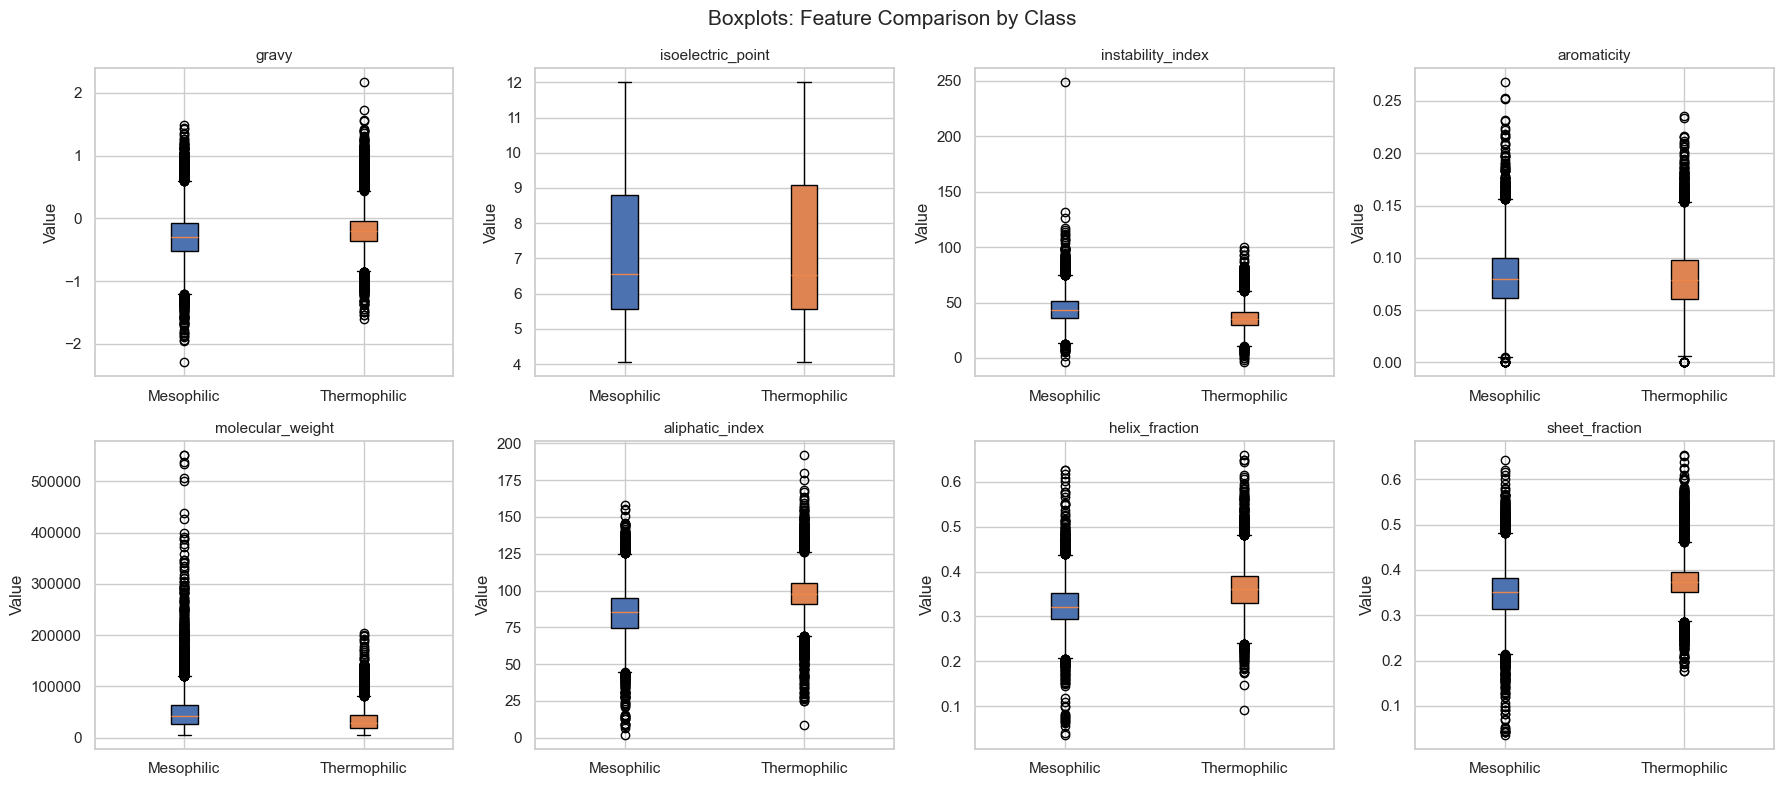

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    # Prepare two lists: one per class, dropping NaN to be safe
    data = [df[df['label']==0][feat].dropna(),
            df[df['label']==1][feat].dropna()]

    # patch_artist=True fills the box with colour
    bp = axes[i].boxplot(data,
                         labels=['Mesophilic', 'Thermophilic'],
                         patch_artist=True)

    # Colour the two boxes differently
    bp['boxes'][0].set_facecolor('#4C72B0')   # blue = mesophilic
    bp['boxes'][1].set_facecolor('#DD8452')   # orange = thermophilic
    axes[i].set_title(feat, fontsize=11)
    axes[i].set_ylabel('Value')

plt.suptitle('Boxplots: Feature Comparison by Class', fontsize=15)
plt.tight_layout()
plt.savefig('../data/boxplots.png', dpi=150)
plt.show()

## Boxplots by class

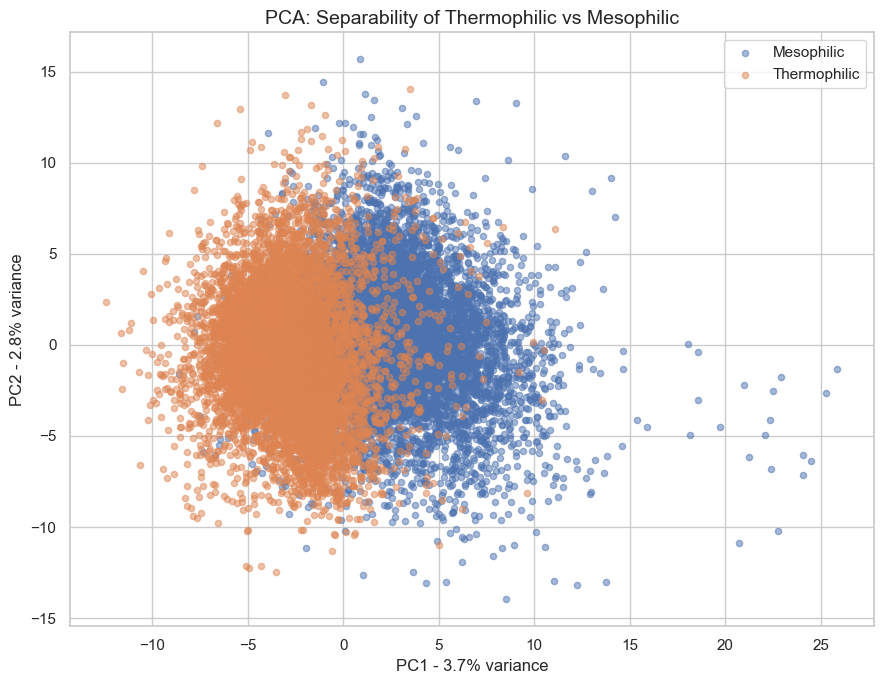

Total variance explained by 2 components: 6.5%


In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Standardise: make all features have mean=0 and std=1
# Necessary because features have very different scales
# (molecular_weight is in thousands, AA fractions are 0-1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reduce to 2 dimensions for visualisation
# random_state=42 ensures the PCA result is reproducible
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Plot each class as a separate scatter colour
fig, ax = plt.subplots(figsize=(9, 7))
for label, name, color in [(0, 'Mesophilic', '#4C72B0'),
                            (1, 'Thermophilic', '#DD8452')]:
    mask = y == label          # boolean index for this class
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=color, label=name, alpha=0.5, s=20)

# Show how much variance each axis explains
ax.set_xlabel(
    f'PC1 - {pca.explained_variance_ratio_[0]*100:.1f}% variance',
    fontsize=12)
ax.set_ylabel(
    f'PC2 - {pca.explained_variance_ratio_[1]*100:.1f}% variance',
    fontsize=12)
ax.set_title('PCA: Separability of Thermophilic vs Mesophilic',
             fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../data/pca_plot.png', dpi=150)
plt.show()

variance_total = sum(pca.explained_variance_ratio_) * 100
print(f"Total variance explained by 2 components: {variance_total:.1f}%")